# 05 - Testing metrics

In [83]:
from pathlib import Path
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import pyreadstat
import matplotlib.pyplot as plt


import ambient_light_epilepsy.nhanes as nhn
import ambient_light_epilepsy.cohort as ch
import ambient_light_epilepsy.lux_metrics as lm
import time


def get_sampling_interval_minutes(df):
    df = df.sort_values("timestamp")
    delta = (df["timestamp"].iloc[1] - df["timestamp"].iloc[0]).total_seconds()
    return delta / 60

## Load a data file

In [47]:
control_s, pwe_s = ch.load_freq_matched_control_groups("G")
p = Path(f"W:/projects/ambient_light_epilepsy_analysis/data/PAXLUX_G/parquet_5min/SEQN_{control_s[100]}_5min.parquet")
pf = pq.ParquetFile(p)
df = pf.read(columns=["timestamp", "mean_lux"]).to_pandas()

Time taken to load parquet with pyarrow: 0.882 s


,timestamp,mean_lux
0,2000-01-06 12:32:30+00:00,46.650000
1,2000-01-06 12:37:30+00:00,14.866667
2,2000-01-06 12:42:30+00:00,8.800000
3,2000-01-06 12:47:30+00:00,0.316667
4,2000-01-06 12:52:30+00:00,0.606667
...,...,...
2301,2000-01-14 12:17:30+00:00,0.000000
2302,2000-01-14 12:22:30+00:00,0.000000
2303,2000-01-14 12:27:30+00:00,0.000000
2304,2000-01-14 12:32:30+00:00,0.000000


## Daytime and nightitme definitions

In [48]:
def compute_mean_daytime_lux(df, day_start=7, day_end=19):
    """
    Computes mean daytime lux.

    Parameters
    ----------
    df : pandas DataFrame
        Must contain columns:
            - 'timestamp' (datetime)
            - 'mean_lux'
    day_start : int
        Start hour (inclusive)
    day_end : int
        End hour (exclusive)

    Returns
    -------
    float
        Mean daytime lux
    """

    hours = df["timestamp"].dt.hour

    mask = (hours >= day_start) & (hours < day_end)

    if mask.sum() == 0:
        return np.nan

    return df.loc[mask, "mean_lux"]#.mean()


def compute_mean_nighttime_lux(df, night_start=22, night_end=5):
    """
    Computes mean nighttime lux.

    Handles windows that cross midnight.

    Parameters
    ----------
    df : pandas DataFrame
        Must contain columns:
            - 'timestamp' (datetime)
            - 'mean_lux'
    night_start : int
        Start hour (inclusive)
    night_end : int
        End hour (exclusive)

    Returns
    -------
    float
        Mean nighttime lux
    """

    hours = df["timestamp"].dt.hour

    if night_start < night_end:
        # Does NOT cross midnight
        mask = (hours >= night_start) & (hours < night_end)
    else:
        # Crosses midnight (e.g., 22–05)
        mask = (hours >= night_start) | (hours < night_end)

    if mask.sum() == 0:
        return np.nan

    return df.loc[mask, "mean_lux"]#.mean()

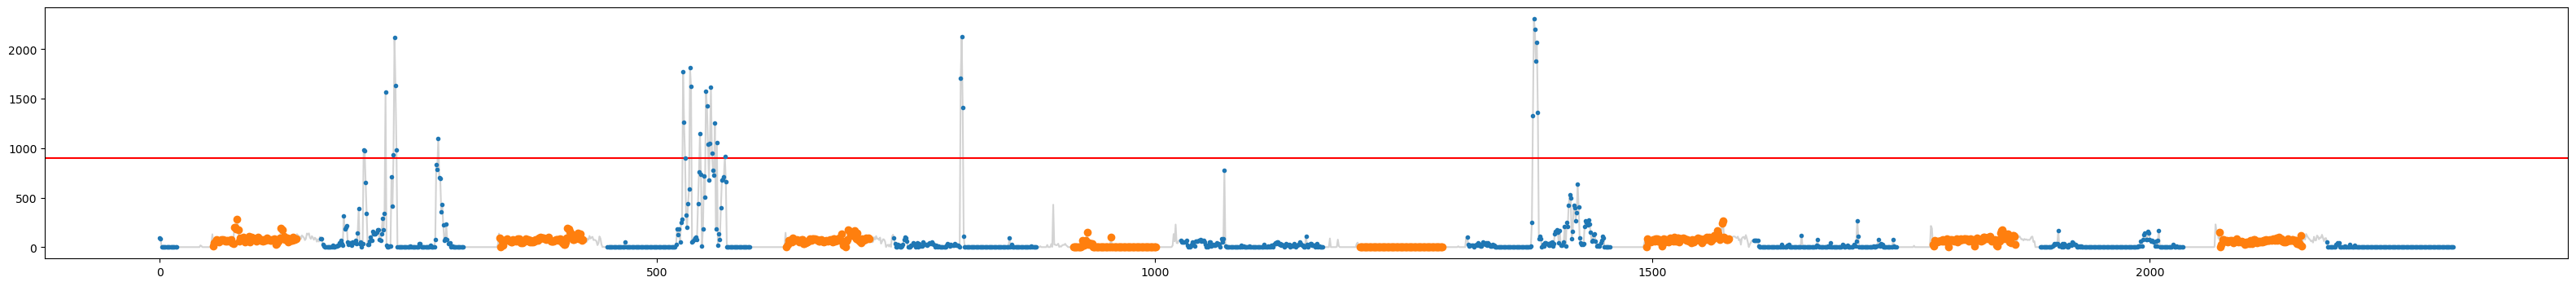

In [104]:
# Load the file
control_s, pwe_s = ch.load_freq_matched_control_groups("G")
p = Path(f"W:/projects/ambient_light_epilepsy_analysis/data/PAXLUX_G/parquet_5min/SEQN_{control_s[4]}_5min.parquet")
pf = pq.ParquetFile(p)
df = pf.read(columns=["timestamp", "mean_lux"]).to_pandas()


# run analysis and plot
fig, ax = plt.subplots(figsize=(40,4))

ax.plot(df['mean_lux'], color='lightgrey')
ax.axhline(900, color='r')

day = compute_mean_daytime_lux(df)
night = compute_mean_nighttime_lux(df)
ax.plot(day, '.')
ax.plot(night, 'o')

## Time above threshold

In [77]:
import numpy as np
import pandas as pd

def get_sampling_interval_minutes(df):
    df = df.sort_values("timestamp")
    delta = (df["timestamp"].iloc[1] - df["timestamp"].iloc[0]).total_seconds()
    return delta / 60


def time_above_threshold_normalized(df, threshold=1000):
    df = df.copy()
    df = df.sort_values("timestamp")
    
    # Detect sampling rate
    epoch_minutes = get_sampling_interval_minutes(df)
    
    # Compute time above threshold
    epochs_above = (df["mean_lux"] > threshold).sum()
    
    # Convert to percentage of recording
    percent_above = epochs_above / len(df)
    
    # Convert to an average mins per day above threshold
    mins_per_day_above = percent_above * 60 * 24
        
    return mins_per_day_above



0.0


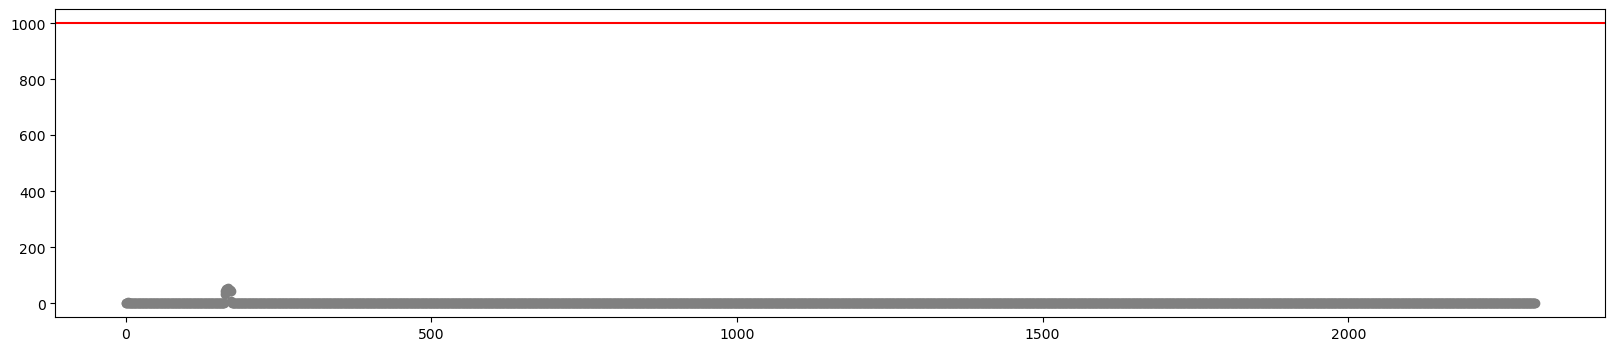

In [131]:
# Load the recording
control_s, pwe_s = ch.load_freq_matched_control_groups("G")
p = Path(f"W:/projects/ambient_light_epilepsy_analysis/data/PAXLUX_G/parquet_5min/SEQN_{control_s[3]}_5min.parquet")
pf = pq.ParquetFile(p)
df = pf.read(columns=["timestamp", "mean_lux"]).to_pandas()


# Run analysis
threshold = 1000
mins, percent = lm.time_above_threshold_normalized(df, threshold=threshold)
print(mins)

# run analysis and plot
fig, ax = plt.subplots(figsize=(20,4))
ax.plot(df['mean_lux'], color='lightgrey')
ax.plot(df['mean_lux'], 'o', color='grey')
ax.axhline(1000, color='r')

## Relative amplitude

In [136]:
def relative_amplitude(df):

    df = df.copy()
    df = df.sort_values("timestamp")
    
    epoch_minutes = lm.get_sampling_interval_minutes(df)
    
    # Average 24h profile
    df["time_of_day"] = df["timestamp"].dt.time
    mean_24h = df.groupby("time_of_day")["mean_lux"].mean()
    
    values = mean_24h.values
    
    samples_per_hour = int(60 / epoch_minutes)
    m10_window = 10 * samples_per_hour
    l5_window = 5 * samples_per_hour
    
    # Circular extension
    extended = np.concatenate([values, values])
    
    # Rolling means
    m10_roll = pd.Series(extended).rolling(m10_window).mean()
    l5_roll = pd.Series(extended).rolling(l5_window).mean()
    
    m10 = m10_roll.max()
    l5 = l5_roll.min()
    
    ra = (m10 - l5) / (m10 + l5)
    
    minutes_per_sample = epoch_minutes
    
    # =========================
    # M10 midpoint
    # =========================
    
    m10_idx = m10_roll.idxmax()
    
    m10_start = m10_idx - m10_window + 1
    m10_midpoint_idx = m10_start + m10_window // 2
    
    m10_midpoint_idx = m10_midpoint_idx % len(values)
    
    m10_midpoint_minutes = m10_midpoint_idx * minutes_per_sample
    
    m10_hours = int(m10_midpoint_minutes // 60)
    m10_minutes = int(m10_midpoint_minutes % 60)
    
    m10_midpoint_time = pd.Timestamp(
        f"{m10_hours:02d}:{m10_minutes:02d}"
    ).time()
    
    # =========================
    # L5 midpoint
    # =========================
    
    l5_idx = l5_roll.idxmin()
    
    l5_start = l5_idx - l5_window + 1
    l5_midpoint_idx = l5_start + l5_window // 2
    
    l5_midpoint_idx = l5_midpoint_idx % len(values)
    
    l5_midpoint_minutes = l5_midpoint_idx * minutes_per_sample
    
    l5_hours = int(l5_midpoint_minutes // 60)
    l5_minutes = int(l5_midpoint_minutes % 60)
    
    l5_midpoint_time = pd.Timestamp(
        f"{l5_hours:02d}:{l5_minutes:02d}"
    ).time()
    
    return (
        m10,
        l5,
        ra,
        m10_midpoint_minutes,
        m10_midpoint_time,
        l5_midpoint_minutes,
        l5_midpoint_time
    )

(np.float64(126.47700848765432),
 np.float64(3.419645833333333),
 np.float64(0.9473482076777275),
 980.0,
 datetime.time(16, 20),
 240.0,
 datetime.time(4, 0))

np.float64(121.54043904320989)

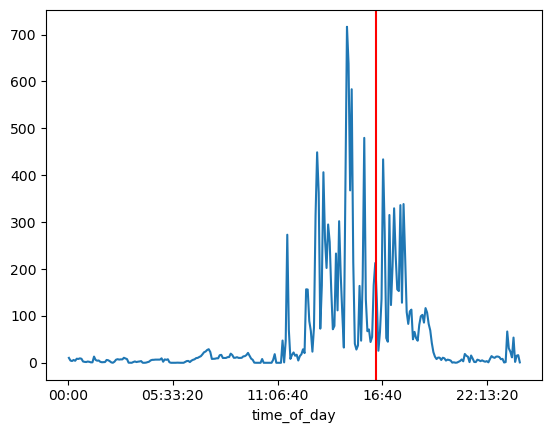

In [138]:
# Load the recording
control_s, pwe_s = ch.load_freq_matched_control_groups("G")
p = Path(f"W:/projects/ambient_light_epilepsy_analysis/data/PAXLUX_G/parquet_5min/SEQN_{control_s[7]}_5min.parquet")
pf = pq.ParquetFile(p)
df = pf.read(columns=["timestamp", "mean_lux"]).to_pandas()

# Calculate relative amplitude, and m10, from data
m10, l5, ra, m10_midpoint_minutes, m10_midpoint_time, l5_midpoint_minutes, l5_midpoint_time = relative_amplitude(df)
display(relative_amplitude(df))

# Approximate the start and end of the m10 window
start = 105
h10 = start + 12*10

# Plot the daily pattern and approximate start and end times 
fig, ax = plt.subplots()
# Average 24h profile
df["time_of_day"] = df["timestamp"].dt.time
mean_24h = df.groupby("time_of_day")["mean_lux"].mean()
mean_24h.plot(ax=ax)
# ax.axvline(mean_24h.index[start], color='r')
# ax.axvline(mean_24h.index[h10], color='r')
ax.axvline(m10_midpoint_time, color='r')


# Print the mean of the m10 window, should align with function 
mean_24h[start:h10].mean()

In [139]:
m10

np.float64(126.47700848765432)

### IS ans IV

In [141]:
def interdaily_stability(df):

    df = df.copy()
    df = df.sort_values("timestamp")

    # mean lux
    mean_lux = df["mean_lux"].mean()

    # extract hour of day
    df["hour"] = df["timestamp"].dt.hour

    # mean lux for each hour
    hourly_mean = df.groupby("hour")["mean_lux"].mean()

    # number of samples
    N = len(df)

    # numerator
    num = N * np.sum((hourly_mean - mean_lux) ** 2)

    # denominator
    denom = 24 * np.sum((df["mean_lux"] - mean_lux) ** 2)

    IS = num / denom

    return IS



def intradaily_variability(df):

    df = df.copy()
    df = df.sort_values("timestamp")

    X = df["mean_lux"].values
    N = len(X)

    mean_lux = np.mean(X)

    # numerator
    diff = np.diff(X)
    num = np.sum(diff ** 2) / (N - 1)

    # denominator
    denom = np.sum((X - mean_lux) ** 2) / N

    IV = num / denom

    return IV




In [142]:
# Load the recording
control_s, pwe_s = ch.load_freq_matched_control_groups("G")
p = Path(f"W:/projects/ambient_light_epilepsy_analysis/data/PAXLUX_G/parquet_5min/SEQN_{control_s[7]}_5min.parquet")
pf = pq.ParquetFile(p)
df = pf.read(columns=["timestamp", "mean_lux"]).to_pandas()


IS = interdaily_stability(df)
IV = intradaily_variability(df)

In [162]:
import numpy as np
import pandas as pd

# create timestamps
timestamps = pd.date_range("2024-01-01", periods=24*60, freq="1min")

# perfect circadian rhythm
lux = 500 * (np.sin(np.linspace(0, 2*np.pi, len(timestamps))) + 1)

df = pd.DataFrame({
    "timestamp": timestamps,
    "mean_lux": lux
})

IS = interdaily_stability(df)

print("IS (perfect rhythm):", IS)


# random light signal

lux_random = np.random.rand(len(timestamps))*500

df_random = pd.DataFrame({
    "timestamp": timestamps,
    "mean_lux": lux_random
})

IS_random = interdaily_stability(df_random)

print("IS (random):", IS_random)

IS (perfect rhythm): 0.9942871657057144
IS (random): 0.010420366436696124


In [157]:
def generate_clustered_array(length=1440, cluster_size=100):
    # Initialize an array of zeros
    arr = np.zeros(length, dtype=int)
    
    # Start at a random initial position
    current_pos = np.random.randint(0, 50)

    while current_pos < length:
        # Randomize the width of the cluster slightly (e.g., between 80 and 120)
        actual_cluster_width = np.random.randint(cluster_size - 20, cluster_size + 21)
        
        # Determine the end index of the cluster, capping at total length
        end_pos = min(current_pos + actual_cluster_width, length)

        # Fill the cluster with 1s
        arr[current_pos:end_pos] = 1

        # Move forward by the cluster width plus a random gap (e.g., 50 to 150)
        gap = np.random.randint(5, 300)
        current_pos = end_pos + gap

    return arr

In [173]:
# smooth circadian signal

lux = 500 * (np.sin(np.linspace(0, 2*np.pi, len(timestamps))) + 1)

df = pd.DataFrame({
    "timestamp": timestamps,
    "mean_lux": lux
})

IV = intradaily_variability(df)

print("IV (smooth):", IV)


# fragmented signal
frag_arr = generate_clustered_array(length=len(df))

lux_frag = lux * frag_arr + np.random.normal(0,200,len(lux))

df_frag = pd.DataFrame({
    "timestamp": timestamps,
    "mean_lux": lux_frag
})

IV_frag = intradaily_variability(df_frag)

print("IV (fragmented):", IV_frag)

fig, ax = plt.subplots()
ax.plot(df["mean_lux"])
ax.plot(df_frag["mean_lux"])

IV (smooth): 1.907827730480399e-05
IV (fragmented): 0.5730769936298591


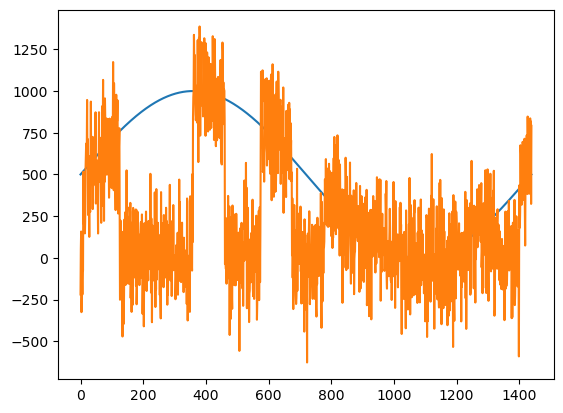

In [149]:
len(df)

1440